# Heart Disease Risk Prediction From Scratch

This notebook predicts heart disease risk using a public Kaggle dataset, but the more important goal is to make the mechanics of logistic regression visible rather than hiding them behind a library call. It is meant to sit somewhere between fundamentals work and an applied classification project.

## Notebook Flow
- inspect the dataset and target balance
- encode and scale the clinical features
- implement logistic regression from scratch
- compare the result with scikit-learn
- end with a conclusion that checks whether the custom model is actually believable

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)


In [2]:
data_path = Path('data/heart.csv')
df = pd.read_csv(data_path)

print(f'Shape: {df.shape}')
df.head()


Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 1. Quick EDA

The target variable is `HeartDisease`, where `1` indicates the presence of heart disease and `0` indicates no detected disease in the dataset label.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [4]:
target_share = df['HeartDisease'].value_counts(normalize=True).sort_index().rename(index={0: 'No disease', 1: 'Heart disease'})
summary = pd.DataFrame({
    'count': df['HeartDisease'].value_counts().sort_index().values,
    'share': target_share.values,
}, index=target_share.index)
summary


,count,share
HeartDisease,,
No disease,410,0.446623
Heart disease,508,0.553377


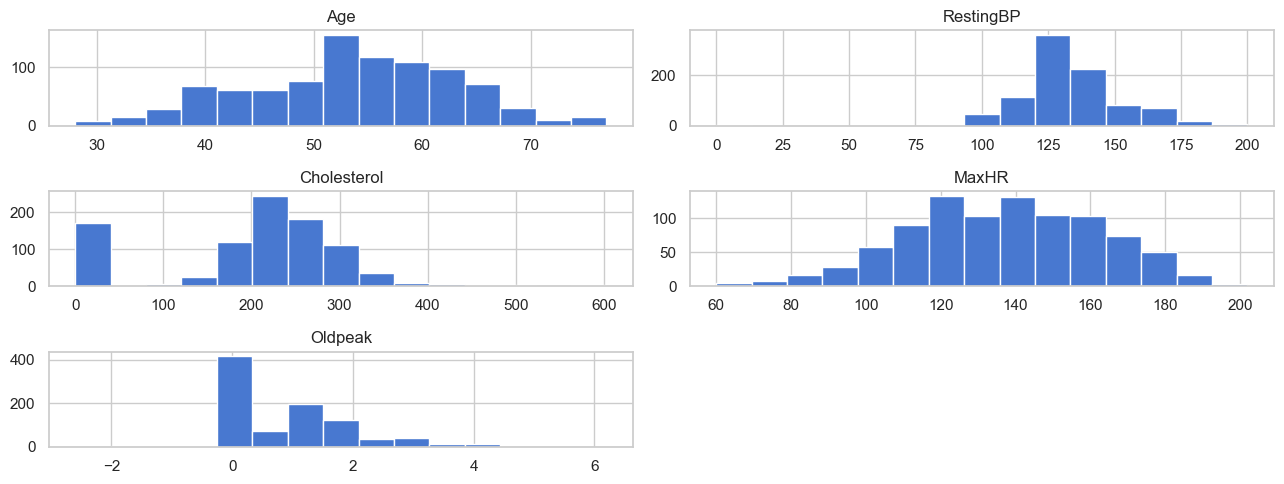

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='HeartDisease', ax=axes[0])
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(['No disease', 'Heart disease'])
axes[0].set_xlabel('Heart disease label')

numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df[numeric_features].hist(ax=axes[1], bins=15)
axes[1].set_title('Numeric Feature Snapshot')
axes[1].grid(False)
plt.tight_layout()


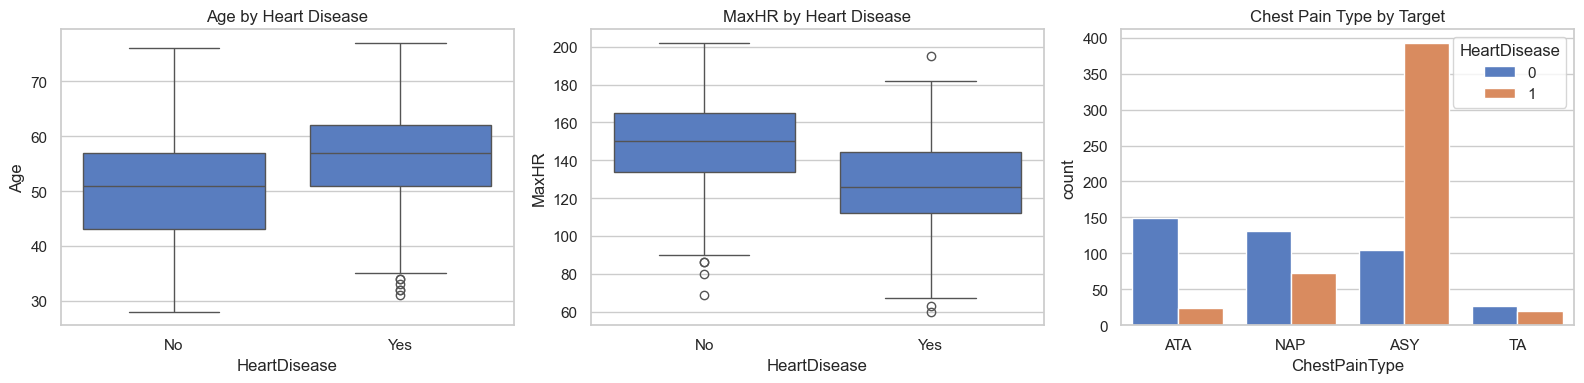

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x='HeartDisease', y='Age', ax=axes[0])
axes[0].set_xticklabels(['No', 'Yes'])
axes[0].set_title('Age by Heart Disease')

sns.boxplot(data=df, x='HeartDisease', y='MaxHR', ax=axes[1])
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].set_title('MaxHR by Heart Disease')

sns.countplot(data=df, x='ChestPainType', hue='HeartDisease', ax=axes[2])
axes[2].set_title('Chest Pain Type by Target')
axes[2].legend(title='HeartDisease')
plt.tight_layout()


### EDA Interpretation

The first set of plots suggests that heart disease status is not explained by one variable alone. The positive class appears slightly older on average, and the `MaxHR` distribution is generally lower for patients with heart disease, which hints at an exercise-related signal.

The clearest visual separation comes from `ChestPainType`. In particular, asymptomatic chest pain is much more common among positive cases, while some of the more typical angina categories appear more often in the negative class. By contrast, variables like cholesterol and resting blood pressure still vary widely inside both groups, so they look more useful in combination than as standalone rules.


## 2. Preprocessing

To keep the custom model focused on optimization rather than raw string handling, the notebook uses one-hot encoding for categorical features and z-score scaling for the final design matrix.


In [7]:
X_df = pd.get_dummies(df.drop(columns='HeartDisease'), drop_first=True).astype(float)
y = df['HeartDisease'].to_numpy(dtype=float)
feature_names = X_df.columns.tolist()

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train = X_train_df.to_numpy(dtype=float)
X_test = X_test_df.to_numpy(dtype=float)

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
train_std[train_std == 0] = 1.0

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Encoded features:', len(feature_names))


Train shape: (734, 15)
Test shape: (184, 15)
Encoded features: 15


## 3. Logistic Regression From Scratch

This implementation uses batch gradient descent with L2 regularization. The goal is not to beat highly optimized libraries, but to show the underlying mechanics clearly.


In [8]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.05, n_iterations=4000, regularization=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.regularization = regularization
        self.weights = None
        self.bias = None
        self.loss_history = []

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        eps = 1e-9
        for _ in range(self.n_iterations):
            linear_output = X @ self.weights + self.bias
            probabilities = self._sigmoid(linear_output)

            loss = (
                -(y * np.log(probabilities + eps) + (1 - y) * np.log(1 - probabilities + eps)).mean()
                + (self.regularization / (2 * n_samples)) * np.sum(self.weights ** 2)
            )
            self.loss_history.append(loss)

            errors = probabilities - y
            gradient_w = (X.T @ errors) / n_samples + (self.regularization / n_samples) * self.weights
            gradient_b = errors.mean()

            self.weights -= self.learning_rate * gradient_w
            self.bias -= self.learning_rate * gradient_b

        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


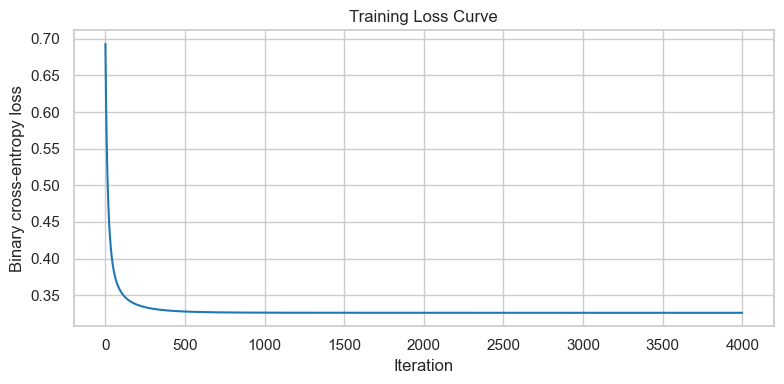

In [9]:
scratch_model = LogisticRegressionScratch(learning_rate=0.05, n_iterations=4000, regularization=0.01)
scratch_model.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(scratch_model.loss_history, color='tab:blue')
ax.set_title('Training Loss Curve')
ax.set_xlabel('Iteration')
ax.set_ylabel('Binary cross-entropy loss')
plt.tight_layout()


## 4. Evaluation

The custom model is evaluated on a held-out test set and then compared to scikit-learn's implementation of logistic regression.


In [10]:
def evaluate_classifier(y_true, y_pred, y_prob, model_name):
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob),
    }

scratch_prob = scratch_model.predict_proba(X_test)
scratch_pred = scratch_model.predict(X_test)

scratch_metrics = evaluate_classifier(y_test, scratch_pred, scratch_prob, 'Logistic Regression (Scratch)')
pd.DataFrame([scratch_metrics]).round(4)


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Scratch),0.8859,0.8716,0.9314,0.9005,0.9292


In [11]:
baseline_model = LogisticRegression(max_iter=5000)
baseline_model.fit(X_train, y_train)

baseline_prob = baseline_model.predict_proba(X_test)[:, 1]
baseline_pred = baseline_model.predict(X_test)

baseline_metrics = evaluate_classifier(y_test, baseline_pred, baseline_prob, 'Logistic Regression (scikit-learn)')
comparison = pd.DataFrame([scratch_metrics, baseline_metrics]).set_index('model').round(4)
comparison


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression (Scratch),0.8859,0.8716,0.9314,0.9005,0.9292
Logistic Regression (scikit-learn),0.8859,0.8716,0.9314,0.9005,0.9297


In [12]:
cm = confusion_matrix(y_test, scratch_pred)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
cm_df


,Predicted 0,Predicted 1
Actual 0,68,14
Actual 1,7,95


In [13]:
print(classification_report(y_test, scratch_pred, target_names=['No disease', 'Heart disease']))


               precision    recall  f1-score   support

   No disease       0.91      0.83      0.87        82
Heart disease       0.87      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.88      0.88       184
 weighted avg       0.89      0.89      0.89       184



## 5. Interpretation

Because logistic regression is inherently interpretable, coefficient inspection gives a simple view of which encoded features are most associated with elevated risk in this model.

The coefficient plot lines up well with the earlier EDA. Chest pain type, ST slope, exercise-induced angina, and sex all appear near the top, which suggests the model is learning a reasonable clinical pattern rather than relying on noise. It is also notable that some familiar numeric variables, such as cholesterol, matter less cleanly on their own than they often do in casual intuition.


In [14]:
coefficient_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': scratch_model.weights,
    'abs_coefficient': np.abs(scratch_model.weights),
}).sort_values('abs_coefficient', ascending=False)

coefficient_table.head(10)


,feature,coefficient,abs_coefficient
8,ChestPainType_NAP,-0.791451,0.791451
14,ST_Slope_Up,-0.762218,0.762218
7,ChestPainType_ATA,-0.661580,0.661580
2,Cholesterol,-0.509186,0.509186
6,Sex_M,0.507655,0.507655
13,ST_Slope_Flat,0.494289,0.494289
12,ExerciseAngina_Y,0.443874,0.443874
3,FastingBS,0.441831,0.441831
9,ChestPainType_TA,-0.343743,0.343743
5,Oldpeak,0.269468,0.269468


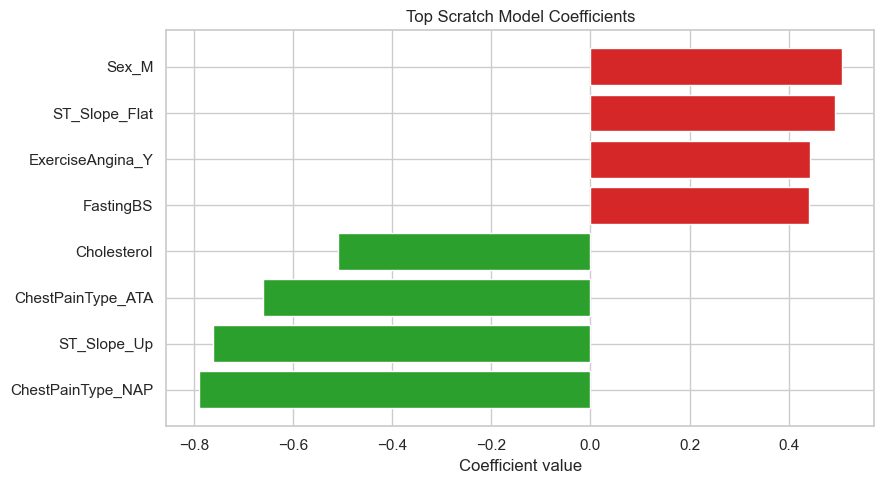

In [15]:
top_features = coefficient_table.head(8).sort_values('coefficient')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_features['feature'], top_features['coefficient'], color=np.where(top_features['coefficient'] > 0, 'tab:red', 'tab:green'))
ax.set_title('Top Scratch Model Coefficients')
ax.set_xlabel('Coefficient value')
plt.tight_layout()


## Conclusion

What makes this notebook satisfying is that the custom model ends up behaving the way it should. The from-scratch implementation lands very close to the scikit-learn baseline, which is a good sign that the optimization and loss setup are doing what they are supposed to do.

That makes the project useful in two ways. It works as a fundamentals exercise because the core algorithm is implemented directly, and it still works as an applied notebook because the final model remains interpretable and performs well on a real dataset.